# 05 - Visualizzazione Territoriale della Capitanata

Visualizzazione del mosaico di riferimento Copernicus CLMS 2023 della Capitanata e della distribuzione geografica dei punti campionati per il dataset.


In [4]:
import sys
import os
from pathlib import Path

if 'google.colab' in sys.modules:
    print("Ambiente Colab rilevato. Inizializzazione in corso...")
    
    # 1. Monta Drive (se non già montato)
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
        
    # Imposta la root del Drive su Colab
    BASE_DIR = Path('/content/drive/MyDrive/Progetto_MLDM')

    GIT_BRANCH = 'refactor-continuo'
    
    # 2. Clona/Aggiorna la repo
    REPO_DIR = '/content/crop-spatial-classification'
    if not os.path.exists(REPO_DIR):
        !git clone -b {GIT_BRANCH} https://github.com/SimoRinaldi/crop-spatial-classification.git {REPO_DIR}
    else:
        !cd {REPO_DIR} && git fetch origin && git checkout -B {GIT_BRANCH} origin/{GIT_BRANCH} && git reset --hard origin/{GIT_BRANCH} && git clean -fd
    
    # 3. Aggancia la cartella per permettere gli import
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
        
    # 4. Installa i requisiti in modo silenzioso
    %pip install -q -r {REPO_DIR}/requirements.txt
    print("Setup ambiente Colab completato! Branch attivo su Colab: ", GIT_BRANCH)
    
else:
    print("Ambiente Locale rilevato. Procedo con l'esecuzione...")
    
    BASE_DIR = Path.cwd().parent

    if str(BASE_DIR) not in sys.path:
        sys.path.append(str(BASE_DIR))

# =============================
# DEFINIZIONE PATH UNIVERSALI
# =============================
DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
INTERIM_DIR = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'

# Test di verifica per assicurarsi che i dati siano accessibili
if RAW_DIR.exists():
    print(f"✅ Collegamento ai dati riuscito! Cartella raw: {RAW_DIR}")
else:
    print(f"❌ Attenzione: Cartella non trovata in {RAW_DIR}. Verifica il nome, il mount o il path locale.")

Ambiente Colab rilevato. Inizializzazione in corso...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 8 (delta 4), reused 8 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 1.98 KiB | 507.00 KiB/s, done.
From https://github.com/SimoRinaldi/crop-spatial-classification
   e87bc24..6332e7a  refactor-continuo -> origin/refactor-continuo
branch 'refactor-continuo' set up to track 'origin/refactor-continuo'.
Reset branch 'refactor-continuo'
Your branch is up to date with 'origin/refactor-continuo'.
HEAD is now at 6332e7a test1 dimensione pallini
Setup ambiente Colab completato! Branch attivo su Colab:  refactor-continuo
✅ Collegamento ai dati riuscito! Cartella raw: /content/drive/MyDrive/Progetto_MLDM/data/raw


In [5]:
import json
import pandas as pd
from pathlib import Path

# Caricamento del dataset e dei metadati dei punti
dataset_path = PROCESSED_DIR / "dataset" / "dataset.parquet"
points_path = INTERIM_DIR / "points.json"
legend_path = PROCESSED_DIR / "legend.json"

df = pd.read_parquet(dataset_path)
df_points = pd.read_json(points_path)

with open(legend_path, "r", encoding="utf-8") as f:
    legend = json.load(f)

print(f"Dataset caricato con {len(df)} campi.")
print(f"Legenda disponibile con {len(legend)} classi colturali.")
display(df[["ID_Campo", "Crop_Name", "Peak_Month", "NDVI_max", "NDVI_min"]].head())

Dataset caricato con 2707 campi.
Legenda disponibile con 21 classi colturali.


,ID_Campo,Crop_Name,Peak_Month,NDVI_max,NDVI_min
0,0,Wheat,5,0.8234,0.1437
1,1,Wheat,3,0.5731,0.0186
2,2,Wheat,3,0.8378,0.1028
3,3,Wheat,5,0.7146,0.0428
4,4,Wheat,4,0.6683,0.0049


### Mappa Tematica e Campi Campionati


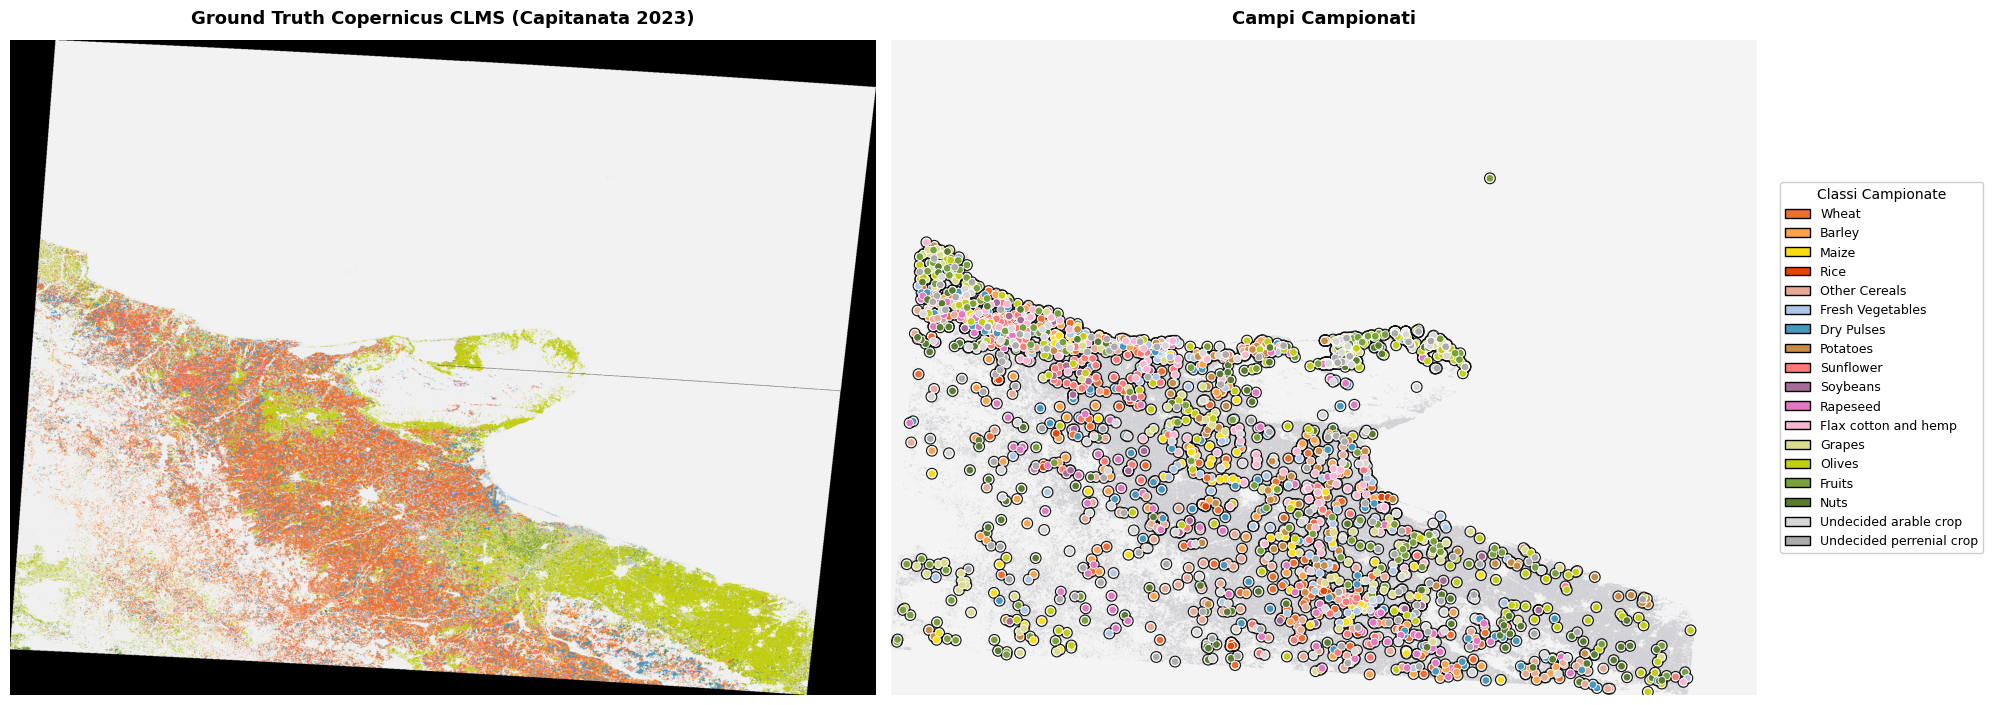

In [ ]:
import rasterio
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.transform import array_bounds
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Uniamo le 4 aree della capitanata in un unico mosaico raster continuo.
# Impostiamo una risoluzione di 0.001 gradi per alleggerire il rendering mantenendo i dettagli.
copernicus_dir = PROCESSED_DIR / "crops_types_yearly_capitanata_4326" / "2023"
tif_files = sorted(list(copernicus_dir.rglob("*.tif")))

src_files = [rasterio.open(f) for f in tif_files]
mosaic, out_trans = merge(src_files, res=(0.001, 0.001), resampling=Resampling.nearest)
for s in src_files:
    s.close()

mosaic = mosaic.squeeze()
# Calcoliamo i confini geografici (bounding box) per posizionare correttamente l'immagine negli assi di matplotlib
left, bottom, right, top = array_bounds(mosaic.shape[0], mosaic.shape[1], out_trans)

# Recuperiamo la tavolozza ufficiale Copernicus dal file .clr, che contiene riga per riga: codice_coltura R G B.
# Normalizziamo i valori RGB tra 0 e 1 per poterli usare direttamente con matplotlib.
clr_file = list(RAW_DIR.rglob("*.clr"))[0]
cmap_dict = {}
with open(clr_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4:
            code = int(parts[0])
            cmap_dict[code] = [int(parts[1]) / 255.0, int(parts[2]) / 255.0, int(parts[3]) / 255.0]

h, w = mosaic.shape

# Costruiamo la mappa tematica di riferimento: assegniamo a ogni pixel del mosaico il colore RGB della coltura corrispondente
rgb_gt = np.ones((h, w, 3), dtype=np.float32) * 0.95
for code, color in cmap_dict.items():
    mask = (mosaic == code)
    if np.any(mask):
        rgb_gt[mask] = color

# Sul secondo grafico la terra è grigia e il mare è bianco
rgb_gray = np.ones((h, w, 3), dtype=np.float32) * 0.96
is_land = (mosaic > 0) & (mosaic < 65534)
rgb_gray[is_land] = [0.82, 0.82, 0.84]

# Assegniamo a ciascun campo campionato il colore ufficiale della sua classe colturale di appartenenza
pts_colors = [cmap_dict.get(int(c), [0.8, 0.2, 0.2]) for c in df_points["code"]]

# Prepariamo la visualizzazione affiancando i due grafici
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Grafico di sinistra: mosaico completo della ground truth
axes[0].imshow(rgb_gt, extent=[left, right, bottom, top], origin="upper")
axes[0].set_title("Ground Truth Copernicus CLMS (Capitanata 2023)", fontsize=13, fontweight="bold", pad=12)
axes[0].axis("off")

# Grafico di destra: sfondo territoriale con i campi campionati.
# Per far risaltare i punti su tutta l'estensione provinciale disegniamo un doppio marker:
# un cerchio esterno nero di contrasto e all'interno il pallino con il colore della coltura.
axes[1].imshow(rgb_gray, extent=[left, right, bottom, top], origin="upper")
axes[1].scatter(
    df_points["lon"], df_points["lat"],
    s=30, facecolors="none", edgecolors="#111111", linewidths=0.6,
    zorder=4
)
axes[1].scatter(
    df_points["lon"], df_points["lat"],
    c=pts_colors, s=12, edgecolors="white", linewidths=0.4,
    zorder=5, label=f"Campi campionati ({len(df_points)} punti)"
)
axes[1].set_title("Campi Campionati", fontsize=13, fontweight="bold", pad=12)
axes[1].axis("off")

# Costruiamo la legenda mostrando solo le colture effettivamente presenti tra i campi campionati
unique_codes = sorted(df_points["code"].unique())
legend_handles = [
    Patch(facecolor=cmap_dict.get(int(c), [0.5, 0.5, 0.5]), edgecolor="black", label=legend.get(str(int(c)), f"Classe {c}"))
    for c in unique_codes if int(c) in cmap_dict
]

axes[1].legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    fontsize=9,
    title="Classi Campionate"
)

plt.tight_layout()
plt.show()
